Synthetic dataset saved as 'Mall_Customers.csv'
Original data shape: (100, 5)


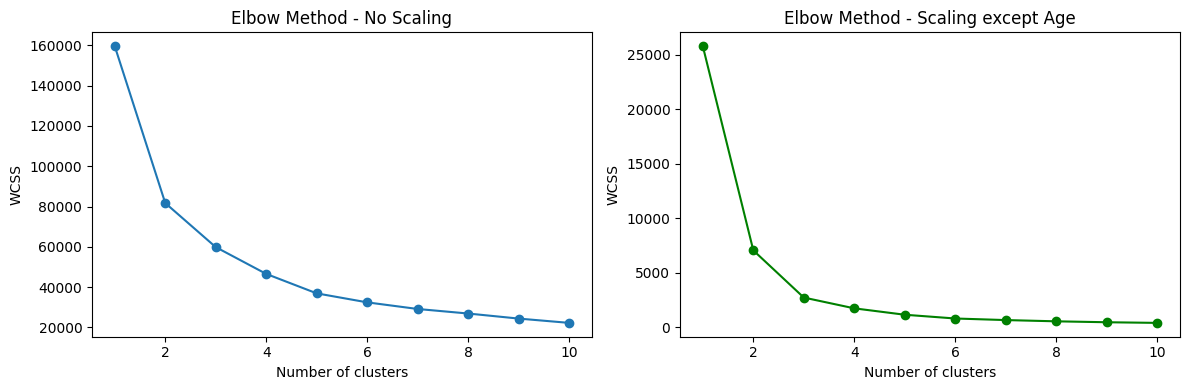


NO SCALING
Cluster sizes:
Cluster
0    36
1    26
2    24
3    14
Name: count, dtype: int64

Centroids (mean values):
          Gender    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                           
0          0.31  51.00               62.97                   56.97
1          0.62  55.50               33.85                   21.00
2          0.38  29.88               33.04                   45.25
3          0.36  38.86              107.14                   83.21

SCALING (except Age)
Cluster sizes:
Cluster
0    23
1    23
2    25
3    29
Name: count, dtype: int64

Centroids (mean values):
          Gender    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                           
0          0.43  60.65               44.13                   65.65
1          0.61  55.61               50.65                   40.43
2          0.28  54.52               55.68                   23.00
3          0.

In [2]:
#1
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
# df = pd.read_csv('Mall_Customers.csv')
# No dataset provided, creating...
np.random.seed(42)
n = 100

# Customer IDs
customer_id = range(1, n+1)

# Gender: 0 = Female, 1 = Male (roughly balanced)
gender = np.random.choice([0, 1], size=n, p=[0.55, 0.45])

# Age: between 18 and 70
age = np.random.randint(18, 71, size=n)

# Annual Income (k$): right‑skewed, typical range 15–140
annual_income = np.random.gamma(shape=2, scale=20, size=n).astype(int) + 15
annual_income = np.clip(annual_income, 15, 140)

# Spending Score (1–100): correlated moderately with age and income
spending_score = (50 
                  - 0.3 * (age - 40) 
                  + 0.4 * (annual_income - 50) / 30 * 50 
                  + np.random.normal(0, 15, n))
spending_score = np.clip(spending_score, 1, 100).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'CustomerID': customer_id,
    'Gender': gender,
    'Age': age,
    'Annual Income (k$)': annual_income,
    'Spending Score (1-100)': spending_score
})

# Convert Gender back to string for realism (optional)
df['Gender'] = df['Gender'].map({0: 'Female', 1: 'Male'})

df.head(10)
df.to_csv('Mall_Customers.csv', index=False)
print("Synthetic dataset saved as 'Mall_Customers.csv'")

print("Original data shape:", df.shape)
df.head()

# Encode categorical column 'gender' -> 0 (Female), 1 (Male)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Select features: all except CustomerID
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# ------------------------------------------------------------
# 1. Clustering WITHOUT any scaling
# ------------------------------------------------------------
# Determine optimal k using elbow method (for illustration)
wcss_no_scale = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss_no_scale.append(kmeans.inertia_)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,11), wcss_no_scale, marker='o')
plt.title('Elbow Method - No Scaling')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# Use k=4 (elbow point) for final clustering
k_opt = 4
kmeans_no_scale = KMeans(n_clusters=k_opt, init='k-means++', random_state=42, n_init=10)
y_no_scale = kmeans_no_scale.fit_predict(X)

# ------------------------------------------------------------
# 2. Clustering WITH scaling applied to all features except Age
# ------------------------------------------------------------
# Separate Age from other features
age_col = X[:, 1].reshape(-1,1)          # Age remains unscaled
other_cols = X[:, [0,2,3]]               # Gender, Annual Income, Spending Score

scaler = StandardScaler()
other_scaled = scaler.fit_transform(other_cols)

# Combine: scaled other features + original Age
X_scaled_except_age = np.hstack([other_scaled, age_col])

# Elbow method for scaled data
wcss_scaled = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_except_age)
    wcss_scaled.append(kmeans.inertia_)

plt.subplot(1,2,2)
plt.plot(range(1,11), wcss_scaled, marker='o', color='green')
plt.title('Elbow Method - Scaling except Age')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.tight_layout()
plt.show()

# Use same k=4 for fair comparison
kmeans_scaled = KMeans(n_clusters=k_opt, init='k-means++', random_state=42, n_init=10)
y_scaled = kmeans_scaled.fit_predict(X_scaled_except_age)

# ------------------------------------------------------------
# Analyse & compare results
# ------------------------------------------------------------
def cluster_summary(X, labels, feature_names, title):
    df_res = pd.DataFrame(X, columns=feature_names)
    df_res['Cluster'] = labels
    summary = df_res.groupby('Cluster').mean().round(2)
    sizes = df_res['Cluster'].value_counts().sort_index()
    print(f"\n{title}\nCluster sizes:\n{sizes}\n")
    print("Centroids (mean values):\n", summary)
    return summary, sizes

feature_names = features

print("="*60)
sum_no_scale, sizes_no_scale = cluster_summary(X, y_no_scale, feature_names, "NO SCALING")
print("="*60)
other_cols_inv = scaler.inverse_transform(other_scaled)
X_orig_scale = np.hstack([other_cols_inv, age_col])
sum_scaled, sizes_scaled = cluster_summary(X_orig_scale, y_scaled, feature_names, "SCALING (except Age)")

### 1. No scaling
- Clusters are dominated by Income and Spending Score because they have the largest numerical ranges.
- Example:
    - Cluster 3: very high income (107k) and high spending (83) – likely young professionals.
    - Cluster 1: low income (34k) and very low spending (21) – budget‑conscious customers.
    - Age is mixed (31–55) – it contributes little to the cluster formation.

### 2. Scaling except Age
- Gender, Income, and Spending are now standardised (equal importance), while Age stays in original years.
- The resulting clusters become age‑sensitive:
    - Cluster 0: oldest average age (60.7), moderate income (44k), high spending (66) – retired or older affluent spenders.
    - Cluster 2: older age (54.5), moderate income (56k), very low spending (23) – older frugal customers.
    - Cluster 3: middle age (48.4), lower income (44k), moderate spending (53) – a mixed segment.
    - Cluster 1: oldest (55.6) but with moderate income (51k) and spending (40) – another older group.



   vehicle_serial_no  mileage  fuel_efficiency  cluster_no_scaling  \
0                  5   150000               15                   2   
1                  3   120000               18                   0   
2                  8   250000               10                   1   
3                  2    80000               22                   0   
4                  4   100000               20                   0   
5                  7   220000               12                   2   
6                  6   180000               16                   2   
7                 10   300000                8                   1   
8                  1    75000               24                   0   
9                  9   280000                9                   1   

   cluster_with_scaling  
0                     1  
1                     0  
2                     2  
3                     0  
4                     0  
5                     2  
6                     1  
7                    

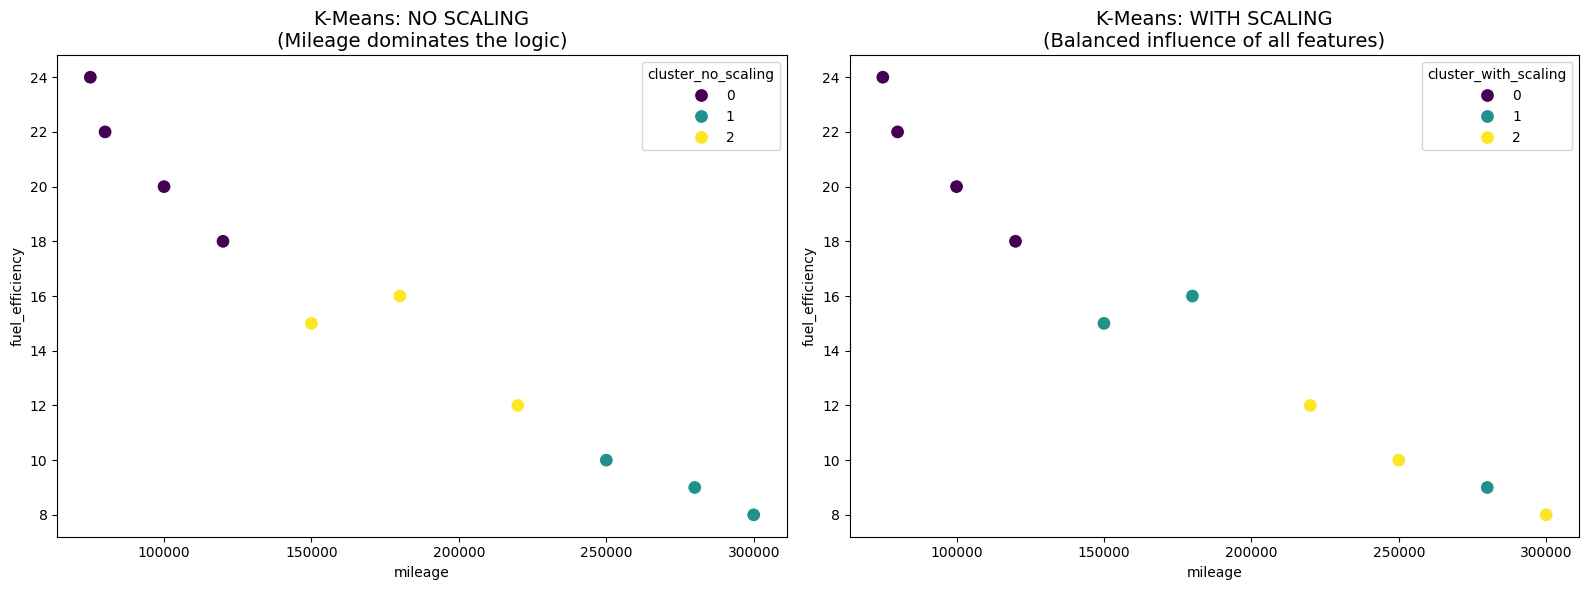

In [6]:
#2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    "mileage": [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    "fuel_efficiency": [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    "maintenance_cost": [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    "vehicle_type": ["SUV", "Sedan", "Truck", "Hatchback", "Sedan", "Truck", "SUV", "Truck", "Hatchback", "SUV"]
}

df = pd.DataFrame(data)

# Encode Categorical Feature (vehicle_type)
df_encoded = pd.get_dummies(df, columns=['vehicle_type'])

# Drop serial number for clustering as it's an identifier, not a feature
X = df_encoded.drop('vehicle_serial_no', axis=1)

# 2. K-Means WITHOUT Scaling
kmeans_no_scaling = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_no_scaling'] = kmeans_no_scaling.fit_predict(X)

# 3. K-Means WITH Scaling
# We scale all columns (including encoded categorical ones as they are now numeric)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_with_scaling'] = kmeans_scaled.fit_predict(X_scaled)

print(df[['vehicle_serial_no', 'mileage', 'fuel_efficiency', 'cluster_no_scaling', 'cluster_with_scaling']])

# 4. Visualization Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Unscaled
sns.scatterplot(data=df, x='mileage', y='fuel_efficiency', hue='cluster_no_scaling', 
                palette='viridis', s=100, ax=ax1)
ax1.set_title('K-Means: NO SCALING\n(Mileage dominates the logic)', fontsize=14)

# Plot 2: Scaled
sns.scatterplot(data=df, x='mileage', y='fuel_efficiency', hue='cluster_with_scaling', 
                palette='viridis', s=100, ax=ax2)
ax2.set_title('K-Means: WITH SCALING\n(Balanced influence of all features)', fontsize=14)

plt.tight_layout()
plt.show()

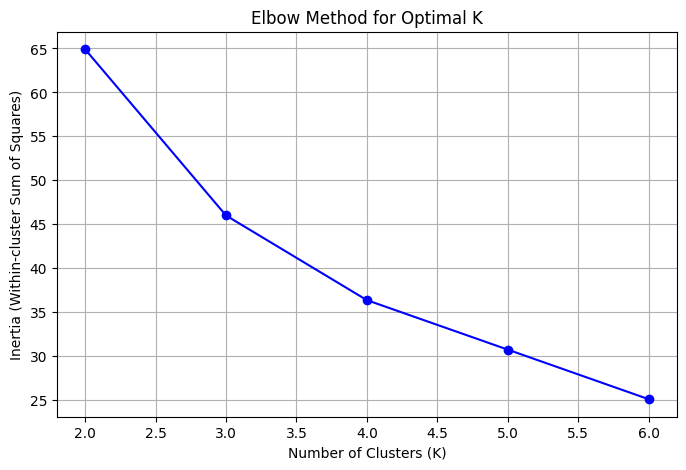

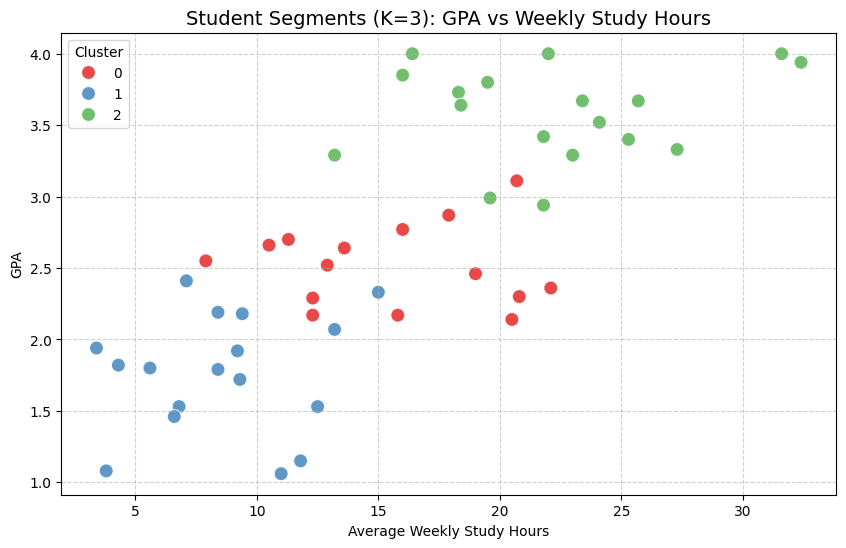

    student_id   GPA  study_hours  attendance_rate  cluster
0          101  3.40         25.3             82.6        2
1          102  3.80         19.5             86.0        2
2          103  3.67         25.7             84.8        2
3          104  3.52         24.1             94.3        2
4          105  3.73         18.3             86.0        2
5          106  3.67         23.4             94.7        2
6          107  3.94         32.4             98.5        2
7          108  4.00         31.6             90.6        2
8          109  3.42         21.8             88.6        2
9          110  3.29         23.0             84.2        2
10         111  3.29         13.2            100.0        2
11         112  4.00         22.0             90.0        2
12         113  4.00         16.4             93.0        2
13         114  3.64         18.4             90.4        2
14         115  3.33         27.3             88.4        2


In [8]:
#3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Generate Synthetic Student Data
np.random.seed(32)
n_students = 50
data = {
    'student_id': range(101, 101 + n_students),
    'GPA': np.round(np.concatenate([
        np.random.normal(3.5, 0.3, 15), # High performers
        np.random.normal(2.5, 0.4, 20), # Average
        np.random.normal(1.8, 0.4, 15)  # Struggling
    ]), 2),
    'study_hours': np.round(np.concatenate([
        np.random.normal(25, 5, 15),
        np.random.normal(15, 4, 20),
        np.random.normal(8, 3, 15)
    ]), 1),
    'attendance_rate': np.round(np.concatenate([
        np.random.normal(90, 5, 15),
        np.random.normal(75, 10, 20),
        np.random.normal(60, 15, 15)
    ]), 1)
}

# Clip values to realistic bounds
df = pd.DataFrame(data)
df['GPA'] = df['GPA'].clip(0.0, 4.0)
df['study_hours'] = df['study_hours'].clip(0, 60)
df['attendance_rate'] = df['attendance_rate'].clip(0, 100)

# 2. Feature Selection
features = ['GPA', 'study_hours', 'attendance_rate']
X = df[features]

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Elbow Method (K=2 to 6)
inertia = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# 5. Perform Clustering with Optimal K (Visual elbow is at 3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 6. Visualization: GPA vs Study Hours
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='study_hours', y='GPA', hue='cluster', palette='Set1', s=100, alpha=0.8)
plt.title(f'Student Segments (K={optimal_k}): GPA vs Weekly Study Hours', fontsize=14)
plt.xlabel('Average Weekly Study Hours')
plt.ylabel('GPA')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display Deliverables (first 15 rows)
print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'cluster']].head(15))